In [28]:
#Load all libraries

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing    # importing dataset
from sklearn.linear_model import LinearRegression        # importing linear Regression algorithms
from sklearn.model_selection import train_test_split     #importing tool that spilting data for traing and testing
from sklearn.metrics import r2_score                     #importing tool that gives our model a score

Step 2: Load Dataset

In [17]:
# Load the real house data
data = fetch_california_housing()

# Put it in a table
df = pd.DataFrame(data.data,columns = data.feature_names)

# Add the price column
df['Price'] = data.target

# How many rows and columns?
print(df.shape)

(20640, 9)


Step 3 — Check Basic Stats

In [20]:
df.describe()

print(data.DESCR)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


Step 4 — Check Missing Values

In [22]:
df.isnull().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
Price         0
dtype: int64

Step 5 — Draw a Graph

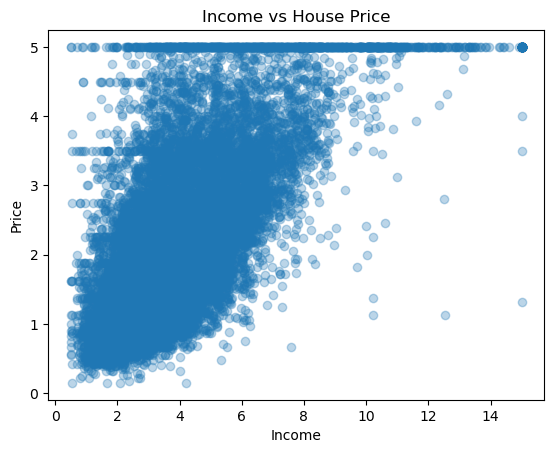

In [23]:
# Does income affect price? let's see!
plt.scatter(df['MedInc'], df['Price'], alpha=0.3)
plt.title('Income vs House Price')
plt.xlabel('Income')
plt.ylabel('Price')
plt.show()

Step 6 — Prepare X and y

In [25]:
# X = inputs (everything except price)
X = df.drop('Price' ,axis = 1)

# y = what we want to predict (only price)
y = df['Price']

print("X Shape : ",X.shape )
print ("y Shape : ",y.shape)

X Shape :  (20640, 8)
y Shape :  (20640,)


Step 7 — Split Data into Train and Test

In [27]:
# Split data into 80% train and 20% test
X_train ,X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train :",len(X_train))   # 80 % 
print("X_train :",len(X_test))    # 20 %

X_train : 16512
X_train : 4128


Step 8 — Train the Model 🧠

In [32]:
# Create the model
model = LinearRegression()

# Train it! (model studies 16,512 houses)
model.fit(X_train, y_train)

print("Model Train Successfully")

Model Train Successfully


Step 9 — Check the Score 📊

In [34]:
#Predict on test houses
y_pred =model.predict(X_test)

# Check the score
score =r2_score(y_test,y_pred)

print("Score :",score)

## Score Meaning:
```
0.9 → Excellent 🟢
0.7 → Good      🟡
0.5 → Poor      🔴

Score : 0.5757877060324512


Step 10 — Predict a Brand New House! 🏠

In [35]:
# Create a brand new house
new_house = pd.DataFrame({
    'MedInc'    : [5.0],
    'HouseAge'  : [10],
    'AveRooms'  : [6.0],
    'AveBedrms' : [1.0],
    'Population': [1000],
    'AveOccup'  : [3.0],
    'Latitude'  : [34.0],
    'Longitude' : [-118.0]
})

# Predict its price
prediction = model.predict(new_house)
print("Predicted Price: $", round(prediction[0] * 100000, 2))

Predicted Price: $ 225254.28
